In [2]:
# ============================================================================
# PARKINSON'S DISEASE DETECTION - PRODUCTION-READY MODEL
# Complete Pipeline: Data Cleaning → Model Training → Evaluation
# ============================================================================

print("="*80)
print("🏥 PARKINSON'S DISEASE DETECTION - VOICE ANALYSIS TOOL")
print("📊 Objective: Binary Classification (0=Healthy, 1=Parkinson's)")
print("🎯 Focus: High accuracy on BOTH train & test (minimize overfitting)")
print("="*80)

# ============================================================================
# STEP 1: IMPORT LIBRARIES
# ============================================================================

print("\n" + "="*80)
print("STEP 1: IMPORTING LIBRARIES")
print("="*80)

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Imbalanced-learn for handling class imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# XGBoost and LightGBM
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost not available")

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except:
    LGBM_AVAILABLE = False
    print("⚠️ LightGBM not available")

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Libraries imported successfully")


🏥 PARKINSON'S DISEASE DETECTION - VOICE ANALYSIS TOOL
📊 Objective: Binary Classification (0=Healthy, 1=Parkinson's)
🎯 Focus: High accuracy on BOTH train & test (minimize overfitting)

STEP 1: IMPORTING LIBRARIES
✓ Libraries imported successfully


In [4]:
# ============================================================================
# STEP 2: LOAD DATASET
# ============================================================================

print("\n" + "="*80)
print("STEP 2: LOADING DATASET")
print("="*80)

# Load from UCI repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data'
df = pd.read_csv(url)

print(f"✓ Dataset loaded successfully")
print(f"  Shape: {df.shape}")
print(f"  Columns: {len(df.columns)}")
print(f"\nFirst 3 rows:")
print(df.head(3))

# Basic info
print(f"\n📊 Dataset Info:")
print(f"  Total samples: {len(df)}")
print(f"  Total features: {df.shape[1]}")
print(f"  Missing values: {df.isnull().sum().sum()}")
print(f"  Duplicates: {df.duplicated().sum()}")


STEP 2: LOADING DATASET
✓ Dataset loaded successfully
  Shape: (195, 24)
  Columns: 24

First 3 rows:
             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   

   Shimmer:DDA      NHR     HNR  status      RPDE       DFA   spread1  \
0      0.06545  0.02211  21.033       1  0.414783  0.815285 -4.813031   
1      0.09403  0.01929  19.085       1  0.458359  0.819521 -4.075192   
2      0.08270  0.01309  20.651       1  0.429895  0.825288 -4.44317


STEP 3: TARGET VARIABLE ANALYSIS
📊 Class Distribution:
  Healthy (0):      48 samples (24.62%)
  Parkinson's (1): 147 samples (75.38%)

  Imbalance Ratio: 3.06:1
  ⚠️ CLASS IMBALANCE DETECTED - Will apply SMOTE


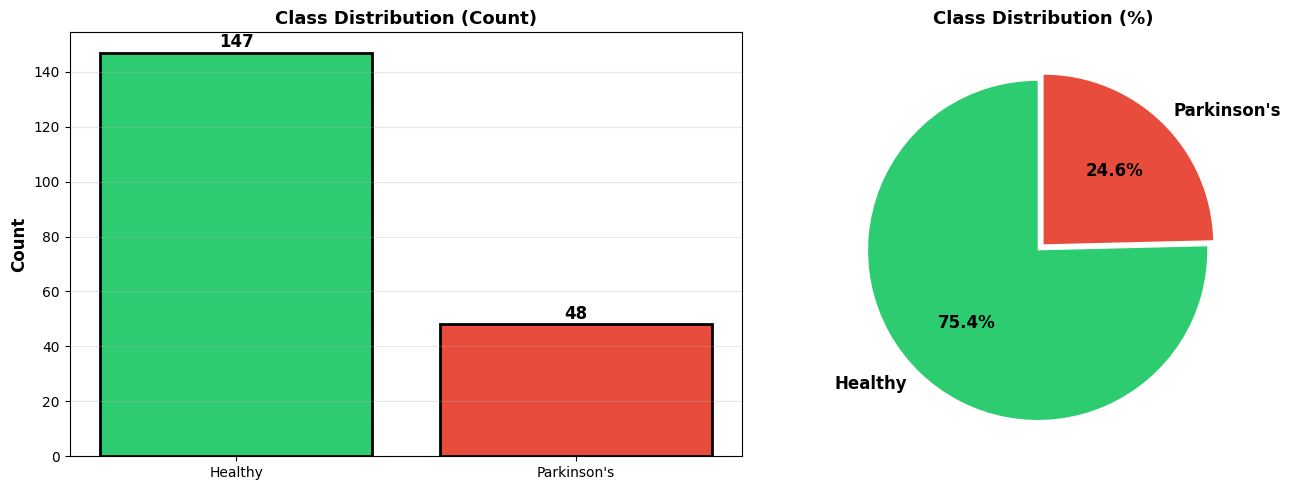

In [5]:
# ============================================================================
# STEP 3: CHECK TARGET BALANCE
# ============================================================================

print("\n" + "="*80)
print("STEP 3: TARGET VARIABLE ANALYSIS")
print("="*80)

# Analyze target distribution
target_counts = df['status'].value_counts()
target_percentages = df['status'].value_counts(normalize=True) * 100

print(f"📊 Class Distribution:")
print(f"  Healthy (0):     {target_counts[0]:3d} samples ({target_percentages[0]:.2f}%)")
print(f"  Parkinson's (1): {target_counts[1]:3d} samples ({target_percentages[1]:.2f}%)")
print(f"\n  Imbalance Ratio: {target_counts[1]/target_counts[0]:.2f}:1")

if target_percentages[0] < 30 or target_percentages[1] < 30:
    print(f"  ⚠️ CLASS IMBALANCE DETECTED - Will apply SMOTE")
else:
    print(f"  ✓ Classes are reasonably balanced")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(['Healthy', 'Parkinson\'s'], target_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=2)
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=12)

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(target_counts.values, labels=['Healthy', 'Parkinson\'s'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            textprops={'fontsize': 12, 'fontweight': 'bold'},
            explode=(0.05, 0))
axes[1].set_title('Class Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
# ============================================================================
# STEP 4: SEPARATE FEATURES AND TARGET
# ============================================================================

print("\n" + "="*80)
print("STEP 4: FEATURE & TARGET SEPARATION")
print("="*80)

# Drop non-feature columns
X = df.drop(['name', 'status'], axis=1)
y = df['status']

print(f"✓ Features and target separated")
print(f"  Features (X): {X.shape}")
print(f"  Target (y): {y.shape}")
print(f"\n📋 Feature columns ({len(X.columns)}):")
print(f"  {list(X.columns)}")

# Check for highly correlated features
print(f"\n🔍 Checking for multicollinearity...")
corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr_features = [column for column in upper_triangle.columns
                      if any(upper_triangle[column] > 0.95)]

if high_corr_features:
    print(f"  ⚠️ Found {len(high_corr_features)} highly correlated features (>0.95):")
    print(f"     {high_corr_features}")
    print(f"  Removing these features to reduce multicollinearity...")
    X = X.drop(columns=high_corr_features)
    print(f"  ✓ Remaining features: {X.shape[1]}")
else:
    print(f"  ✓ No severe multicollinearity detected")


STEP 4: FEATURE & TARGET SEPARATION
✓ Features and target separated
  Features (X): (195, 22)
  Target (y): (195,)

📋 Feature columns (22):
  ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

🔍 Checking for multicollinearity...
  ⚠️ Found 9 highly correlated features (>0.95):
     ['MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'PPE']
  Removing these features to reduce multicollinearity...
  ✓ Remaining features: 13


In [7]:
# ============================================================================
# STEP 5: TRAIN-TEST SPLIT
# ============================================================================

print("\n" + "="*80)
print("STEP 5: TRAIN-TEST SPLIT")
print("="*80)

# Split with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,  # 75% train, 25% test
    random_state=RANDOM_STATE,
    stratify=y  # Maintain class distribution
)

print(f"✓ Data split completed")
print(f"  Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\n📊 Class distribution in splits:")
print(f"  Training   - Healthy: {(y_train==0).sum()}, Parkinson's: {(y_train==1).sum()}")
print(f"  Test       - Healthy: {(y_test==0).sum()}, Parkinson's: {(y_test==1).sum()}")


STEP 5: TRAIN-TEST SPLIT
✓ Data split completed
  Training set:   146 samples (74.9%)
  Test set:       49 samples (25.1%)

📊 Class distribution in splits:
  Training   - Healthy: 36, Parkinson's: 110
  Test       - Healthy: 12, Parkinson's: 37


In [8]:
# ============================================================================
# STEP 6: HANDLING CLASS IMBALANCE (SMOTE)
# ============================================================================

print("\n" + "="*80)
print("STEP 6: HANDLING CLASS IMBALANCE WITH SMOTE")
print("="*80)

# Check train set balance
train_counts = y_train.value_counts()
imbalance_ratio = train_counts[1] / train_counts[0]

print(f"📊 Training set imbalance:")
print(f"  Healthy (0): {train_counts[0]}")
print(f"  Parkinson's (1): {train_counts[1]}")
print(f"  Ratio: {imbalance_ratio:.2f}:1")

# Apply SMOTE only if imbalanced
if imbalance_ratio > 2 or imbalance_ratio < 0.5:
    print(f"\n⚠️ Applying SMOTE to balance classes...")

    # Use k_neighbors carefully (must be <= minority class size - 1)
    minority_size = min(train_counts[0], train_counts[1])
    k_neighbors = min(3, minority_size - 1)

    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

    print(f"  ✓ SMOTE applied (k_neighbors={k_neighbors})")
    print(f"  After SMOTE:")
    print(f"    Healthy (0): {(y_train_balanced==0).sum()}")
    print(f"    Parkinson's (1): {(y_train_balanced==1).sum()}")
    print(f"    New ratio: {(y_train_balanced==1).sum()/(y_train_balanced==0).sum():.2f}:1")
else:
    print(f"  ✓ Classes are balanced, SMOTE not needed")
    X_train_balanced = X_train.copy()
    y_train_balanced = y_train.copy()


STEP 6: HANDLING CLASS IMBALANCE WITH SMOTE
📊 Training set imbalance:
  Healthy (0): 36
  Parkinson's (1): 110
  Ratio: 3.06:1

⚠️ Applying SMOTE to balance classes...
  ✓ SMOTE applied (k_neighbors=3)
  After SMOTE:
    Healthy (0): 110
    Parkinson's (1): 110
    New ratio: 1.00:1


In [9]:
# ============================================================================
# STEP 7: FEATURE SCALING
# ============================================================================

print("\n" + "="*80)
print("STEP 7: FEATURE SCALING")
print("="*80)

# Use RobustScaler (better for outliers)
scaler = RobustScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Features scaled using RobustScaler")
print(f"  Scaler fitted on: {X_train_balanced.shape[0]} training samples")
print(f"  Applied to test set: {X_test.shape[0]} samples")

print(f"\n📊 Scaling verification:")
print(f"  Training set - Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")
print(f"  Test set     - Mean: {X_test_scaled.mean():.4f}, Std: {X_test_scaled.std():.4f}")


STEP 7: FEATURE SCALING
✓ Features scaled using RobustScaler
  Scaler fitted on: 220 training samples
  Applied to test set: 49 samples

📊 Scaling verification:
  Training set - Mean: 0.1821, Std: 1.1685
  Test set     - Mean: 0.1768, Std: 0.8804


In [10]:
# ============================================================================
# STEP 8: MODEL TRAINING (MULTIPLE MODELS)
# ============================================================================

print("\n" + "="*80)
print("STEP 8: MODEL TRAINING")
print("="*80)

# Define models with REGULARIZATION to prevent overfitting
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0,  # Regularization strength
        penalty='l2',
        solver='lbfgs',
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=8,  # Limit depth to prevent overfitting
        min_samples_split=10,  # Require more samples to split
        min_samples_leaf=4,  # Require more samples in leaf
        max_features='sqrt',
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,  # Lower learning rate
        max_depth=3,  # Shallow trees
        subsample=0.8,  # Use 80% of data
        random_state=RANDOM_STATE
    ),

    'SVM (RBF)': SVC(
        C=1.0,  # Regularization
        kernel='rbf',
        gamma='scale',
        probability=True,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    )
}

# Add XGBoost if available
if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,  # L1 regularization
        reg_lambda=1.0,  # L2 regularization
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False
    )

# Training results storage
train_results = {}

print(f"\n🚀 Training {len(models)} models...")
print("-" * 80)

for name, model in models.items():
    print(f"\n⏳ Training {name}...")

    # Train the model
    model.fit(X_train_scaled, y_train_balanced)

    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Calculate metrics
    train_acc = accuracy_score(y_train_balanced, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_results[name] = {
        'model': model,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'overfitting_gap': train_acc - test_acc,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred
    }

    print(f"  ✓ {name} trained")
    print(f"    Train Accuracy: {train_acc:.4f}")
    print(f"    Test Accuracy:  {test_acc:.4f}")
    print(f"    Gap (Overfitting): {train_acc - test_acc:.4f}")


STEP 8: MODEL TRAINING

🚀 Training 5 models...
--------------------------------------------------------------------------------

⏳ Training Logistic Regression...
  ✓ Logistic Regression trained
    Train Accuracy: 0.8409
    Test Accuracy:  0.7755
    Gap (Overfitting): 0.0654

⏳ Training Random Forest...
  ✓ Random Forest trained
    Train Accuracy: 0.9864
    Test Accuracy:  0.9388
    Gap (Overfitting): 0.0476

⏳ Training Gradient Boosting...
  ✓ Gradient Boosting trained
    Train Accuracy: 1.0000
    Test Accuracy:  0.9388
    Gap (Overfitting): 0.0612

⏳ Training SVM (RBF)...
  ✓ SVM (RBF) trained
    Train Accuracy: 0.8773
    Test Accuracy:  0.7755
    Gap (Overfitting): 0.1018

⏳ Training XGBoost...
  ✓ XGBoost trained
    Train Accuracy: 1.0000
    Test Accuracy:  0.9184
    Gap (Overfitting): 0.0816



STEP 9: OVERFITTING ANALYSIS

📊 Overfitting Assessment:
Model                     Train Acc    Test Acc     Gap        Status
--------------------------------------------------------------------------------
Logistic Regression       0.8409       0.7755       0.0654     ✓ Good
Random Forest             0.9864       0.9388       0.0476     ✓ Excellent
Gradient Boosting         1.0000       0.9388       0.0612     ✓ Good
SVM (RBF)                 0.8773       0.7755       0.1018     ⚠️ Moderate
XGBoost                   1.0000       0.9184       0.0816     ✓ Good


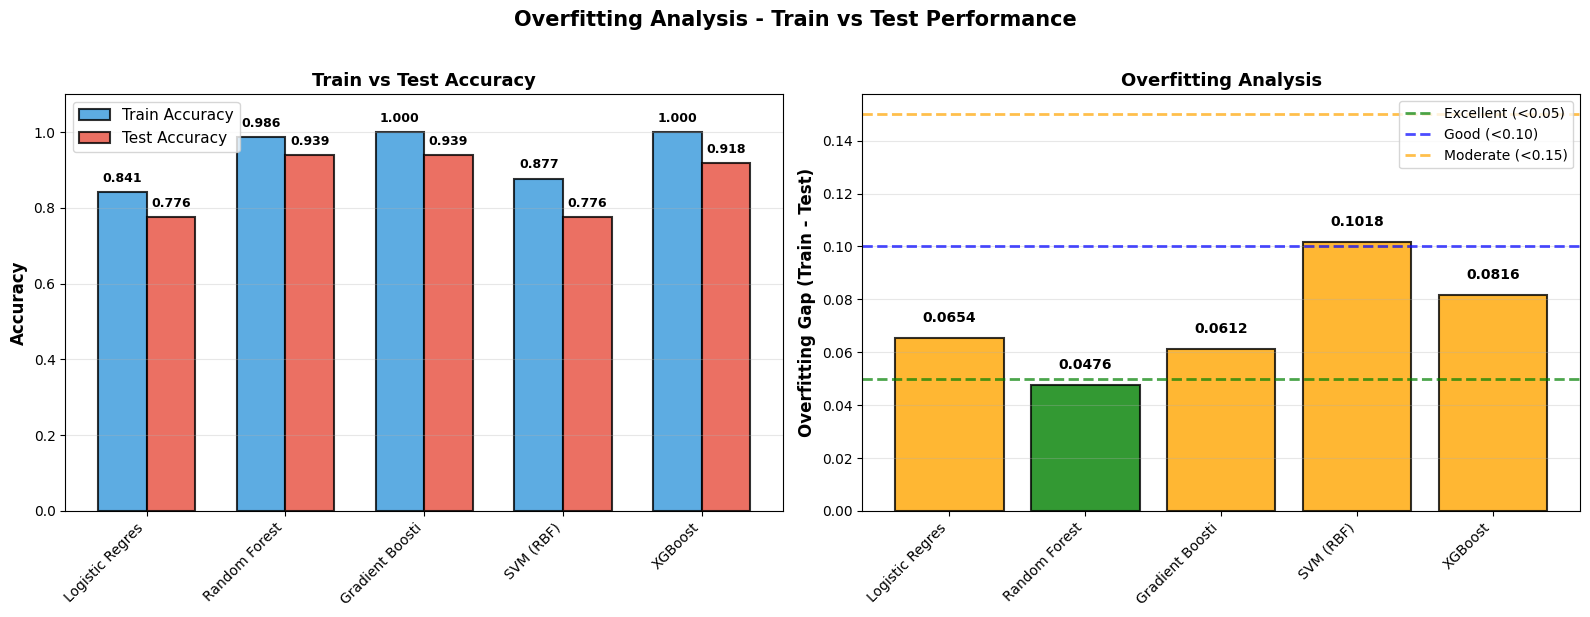


🏆 BEST MODEL (Least Overfitting + Best Test Accuracy):
   Model: Random Forest
   Train Accuracy: 0.9864
   Test Accuracy: 0.9388
   Overfitting Gap: 0.0476


In [11]:
# ============================================================================
# STEP 9: CHECK FOR OVERFITTING
# ============================================================================

print("\n" + "="*80)
print("STEP 9: OVERFITTING ANALYSIS")
print("="*80)

# Analyze overfitting for each model
print(f"\n📊 Overfitting Assessment:")
print("="*80)
print(f"{'Model':<25} {'Train Acc':<12} {'Test Acc':<12} {'Gap':<10} {'Status'}")
print("-" * 80)

for name, results in train_results.items():
    gap = results['overfitting_gap']

    # Determine overfitting status
    if gap < 0.05:
        status = "✓ Excellent"
        color = "green"
    elif gap < 0.10:
        status = "✓ Good"
        color = "blue"
    elif gap < 0.15:
        status = "⚠️ Moderate"
        color = "orange"
    else:
        status = "❌ High"
        color = "red"

    print(f"{name:<25} {results['train_accuracy']:<12.4f} {results['test_accuracy']:<12.4f} {gap:<10.4f} {status}")

print("="*80)

# Visualize overfitting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train vs Test Accuracy
model_names = list(train_results.keys())
train_accs = [train_results[name]['train_accuracy'] for name in model_names]
test_accs = [train_results[name]['test_accuracy'] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = axes[0].bar(x - width/2, train_accs, width, label='Train Accuracy',
                    color='#3498db', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = axes[0].bar(x + width/2, test_accs, width, label='Test Accuracy',
                    color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1.5)

axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Train vs Test Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([name[:15] for name in model_names], rotation=45, ha='right')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.1])

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.3f}', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')

# Overfitting gap
gaps = [train_results[name]['overfitting_gap'] for name in model_names]
colors_gap = ['green' if gap < 0.05 else 'orange' if gap < 0.15 else 'red'
              for gap in gaps]

bars = axes[1].bar(model_names, gaps, color=colors_gap, alpha=0.8,
                   edgecolor='black', linewidth=1.5)
axes[1].axhline(y=0.05, color='green', linestyle='--', linewidth=2,
                label='Excellent (<0.05)', alpha=0.7)
axes[1].axhline(y=0.10, color='blue', linestyle='--', linewidth=2,
                label='Good (<0.10)', alpha=0.7)
axes[1].axhline(y=0.15, color='orange', linestyle='--', linewidth=2,
                label='Moderate (<0.15)', alpha=0.7)
axes[1].set_ylabel('Overfitting Gap (Train - Test)', fontsize=12, fontweight='bold')
axes[1].set_title('Overfitting Analysis', fontsize=13, fontweight='bold')
axes[1].set_xticklabels([name[:15] for name in model_names], rotation=45, ha='right')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for bar, gap in zip(bars, gaps):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{gap:.4f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

plt.suptitle('Overfitting Analysis - Train vs Test Performance',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Select best model (lowest overfitting gap + highest test accuracy)
best_model_name = min(train_results, key=lambda x:
                      (train_results[x]['overfitting_gap'],
                       -train_results[x]['test_accuracy']))

print(f"\n🏆 BEST MODEL (Least Overfitting + Best Test Accuracy):")
print(f"   Model: {best_model_name}")
print(f"   Train Accuracy: {train_results[best_model_name]['train_accuracy']:.4f}")
print(f"   Test Accuracy: {train_results[best_model_name]['test_accuracy']:.4f}")
print(f"   Overfitting Gap: {train_results[best_model_name]['overfitting_gap']:.4f}")



STEP 10: TEST SET PREDICTIONS & ANALYSIS
✓ Predictions generated for 49 test samples

📊 Detailed Test Set Metrics:
  Accuracy:  0.9388
  Precision: 0.9722 (PPV - Positive Predictive Value)
  Recall:    0.9459 (Sensitivity - True Positive Rate)
  F1-Score:  0.9589
  ROC-AUC:   0.9752


In [13]:
# ============================================================================
# STEP 11: COMPREHENSIVE EVALUATION
# ============================================================================

print("\n" + "="*80)
print("STEP 11: COMPREHENSIVE EVALUATION")
print("="*80)

# Classification Report
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_test_pred,
                           target_names=['Healthy', 'Parkinson\'s'],
                           digits=4))

# Calculate confusion matrix components
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

# Calculate additional clinical metrics
sensitivity = tp / (tp + fn)  # Recall
specificity = tn / (tn + fp)
ppv = tp / (tp + fp)  # Precision
npv = tn / (tn + fn)

print(f"\n🏥 Clinical Performance Metrics:")
print(f"  Sensitivity (TPR): {sensitivity:.4f} - Detects {sensitivity*100:.1f}% of Parkinson's cases")
print(f"  Specificity (TNR): {specificity:.4f} - Correctly identifies {specificity*100:.1f}% of healthy")
print(f"  PPV (Precision):   {ppv:.4f} - {ppv*100:.1f}% of positive predictions are correct")
print(f"  NPV:               {npv:.4f} - {npv*100:.1f}% of negative predictions are correct")

print(f"\n📊 Confusion Matrix Components:")
print(f"  True Negatives (TN):  {tn} - Healthy correctly identified")
print(f"  False Positives (FP): {fp} - Healthy misclassified as PD")
print(f"  False Negatives (FN): {fn} - PD cases missed")
print(f"  True Positives (TP):  {tp} - PD correctly detected")


STEP 11: COMPREHENSIVE EVALUATION

📋 Classification Report:
              precision    recall  f1-score   support

     Healthy     0.8462    0.9167    0.8800        12
 Parkinson's     0.9722    0.9459    0.9589        37

    accuracy                         0.9388        49
   macro avg     0.9092    0.9313    0.9195        49
weighted avg     0.9413    0.9388    0.9396        49


🏥 Clinical Performance Metrics:
  Sensitivity (TPR): 0.9459 - Detects 94.6% of Parkinson's cases
  Specificity (TNR): 0.9167 - Correctly identifies 91.7% of healthy
  PPV (Precision):   0.9722 - 97.2% of positive predictions are correct
  NPV:               0.8462 - 84.6% of negative predictions are correct

📊 Confusion Matrix Components:
  True Negatives (TN):  11 - Healthy correctly identified
  False Positives (FP): 1 - Healthy misclassified as PD
  False Negatives (FN): 2 - PD cases missed
  True Positives (TP):  35 - PD correctly detected



STEP 12: CONFUSION MATRIX VISUALIZATION


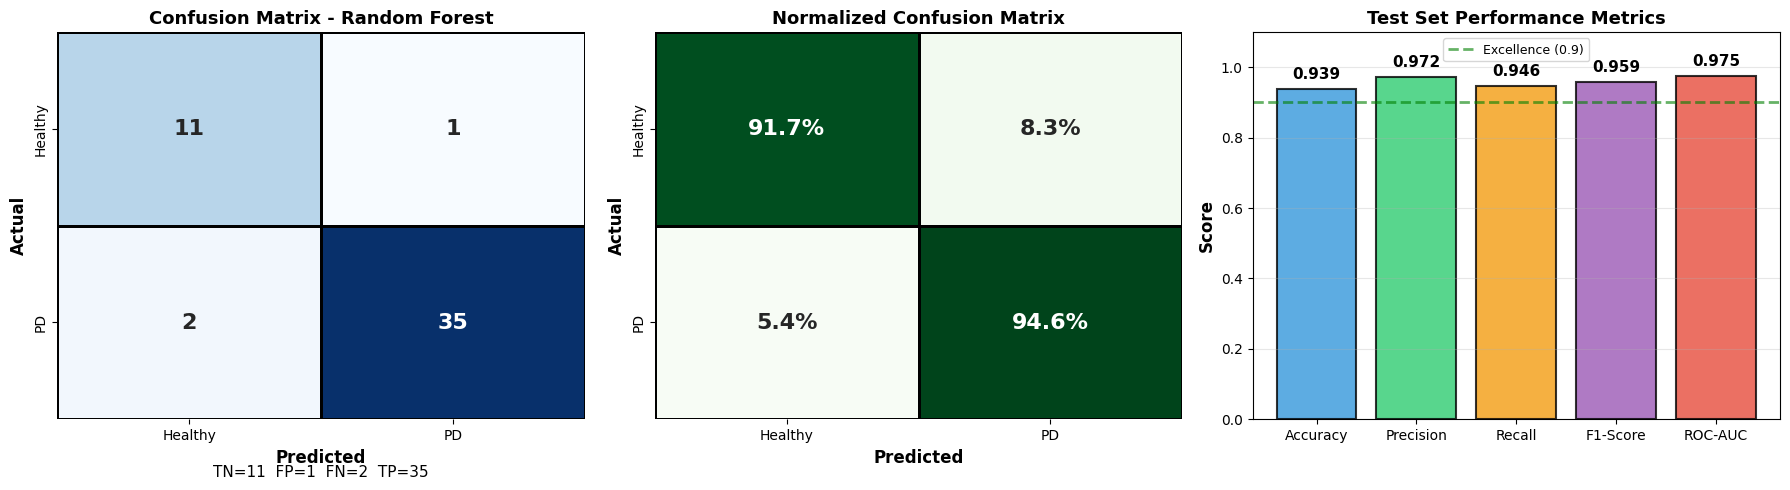

In [14]:
# ============================================================================
# STEP 12: CONFUSION MATRIX VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print("STEP 12: CONFUSION MATRIX VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Healthy', 'PD'],
            yticklabels=['Healthy', 'PD'],
            annot_kws={'fontsize': 16, 'fontweight': 'bold'},
            linewidths=2, linecolor='black')
axes[0].set_title(f'Confusion Matrix - {best_model_name}',
                 fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[0].text(0.5, -0.15, f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
            ha='center', transform=axes[0].transAxes, fontsize=11)

# Normalized (percentages)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Greens', cbar=False, ax=axes[1],
            xticklabels=['Healthy', 'PD'],
            yticklabels=['Healthy', 'PD'],
            annot_kws={'fontsize': 16, 'fontweight': 'bold'},
            linewidths=2, linecolor='black')
axes[1].set_title('Normalized Confusion Matrix',
                 fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12, fontweight='bold')

# Performance metrics
metrics_values = [
    train_results[best_model_name]['test_accuracy'],
    test_precision,
    test_recall,
    test_f1,
    test_auc
]
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors_metrics = ['#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#e74c3c']

bars = axes[2].bar(metrics_labels, metrics_values, color=colors_metrics,
                   alpha=0.8, edgecolor='black', linewidth=1.5)
axes[2].set_ylim([0, 1.1])
axes[2].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[2].set_title('Test Set Performance Metrics',
                 fontsize=13, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
axes[2].axhline(y=0.9, color='green', linestyle='--', linewidth=2,
               label='Excellence (0.9)', alpha=0.6)
axes[2].legend(fontsize=9)

# Add value labels
for bar, val in zip(bars, metrics_values):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


STEP 13: CROSS-VALIDATION (5-FOLD)

⏳ Performing 5-fold cross-validation on best model...
   Model: Random Forest

✓ Cross-validation completed

📊 Cross-Validation Results (5-Fold):
  Fold scores: ['0.8000', '0.8621', '0.8621', '0.8621', '0.7931']
  Mean CV Accuracy: 0.8359
  Std Dev:          0.0322
  Min:              0.7931
  Max:              0.8621

  Stability: ★★★ Excellent (low variance)

📈 Comprehensive CV Metrics:
  Metric          Mean     Std      Min      Max
  -------------------------------------------------------
  Accuracy      0.8359   0.0322   0.7931   0.8621
  Precision     0.9099   0.0373   0.8462   0.9500
  Recall        0.8727   0.0782   0.7727   1.0000
  F1-Score      0.8875   0.0281   0.8500   0.9167
  ROC-AUC       0.9390   0.0134   0.9156   0.9545


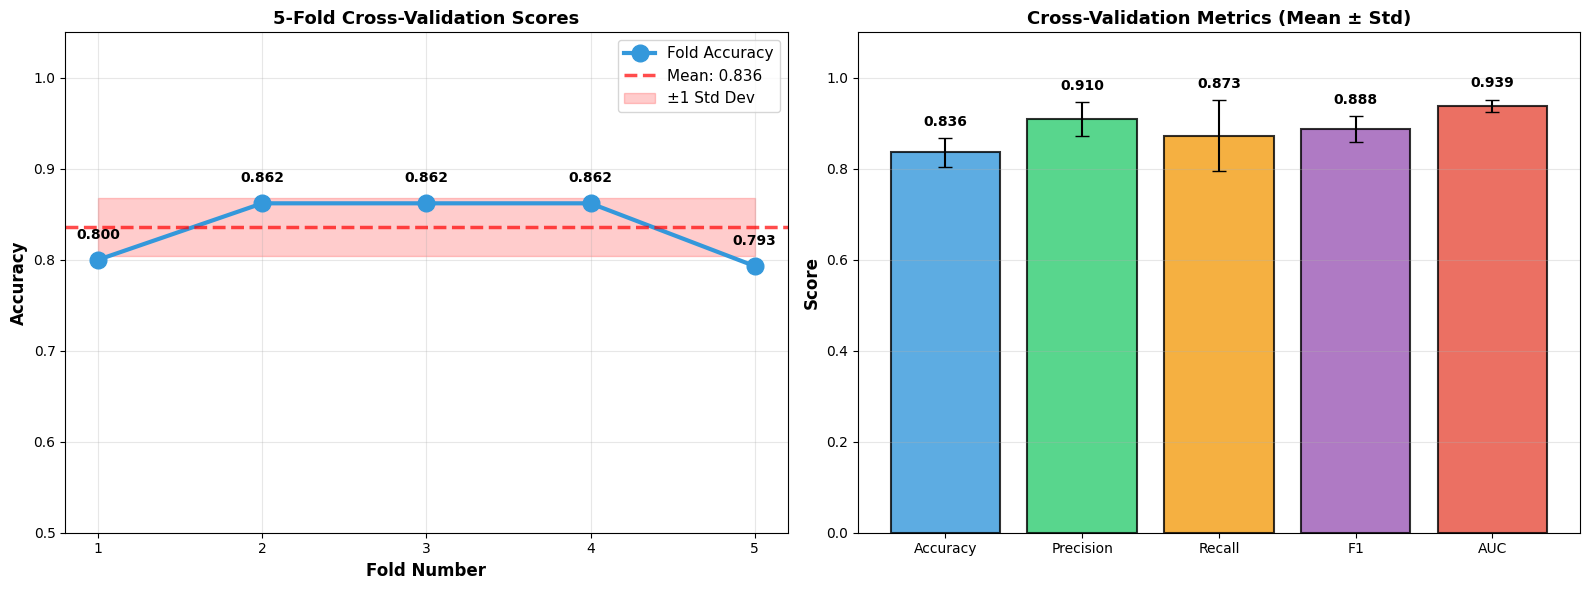

In [15]:
# ============================================================================
# STEP 13: CROSS-VALIDATION - COMPLETE
# ============================================================================

print("\n" + "="*80)
print("STEP 13: CROSS-VALIDATION (5-FOLD)")
print("="*80)

print(f"\n⏳ Performing 5-fold cross-validation on best model...")
print(f"   Model: {best_model_name}")

# Perform cross-validation on the ORIGINAL training data (before SMOTE)
# This gives a more realistic estimate
cv_scores = cross_val_score(
    best_model, X_train, y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print(f"\n✓ Cross-validation completed")
print(f"\n📊 Cross-Validation Results (5-Fold):")
print(f"  Fold scores: {[f'{score:.4f}' for score in cv_scores]}")
print(f"  Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"  Std Dev:          {cv_scores.std():.4f}")
print(f"  Min:              {cv_scores.min():.4f}")
print(f"  Max:              {cv_scores.max():.4f}")

# Assess CV stability
if cv_scores.std() < 0.05:
    cv_stability = "★★★ Excellent (low variance)"
elif cv_scores.std() < 0.10:
    cv_stability = "★★ Good"
else:
    cv_stability = "★ High variance - model unstable"

print(f"\n  Stability: {cv_stability}")

# Additional CV metrics
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    best_model, X_train, y_train,
    cv=5,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
    return_train_score=True,
    n_jobs=-1
)

print(f"\n📈 Comprehensive CV Metrics:")
print(f"  Metric          Mean     Std      Min      Max")
print(f"  {'-'*55}")
print(f"  Accuracy      {cv_results['test_accuracy'].mean():.4f}   {cv_results['test_accuracy'].std():.4f}   {cv_results['test_accuracy'].min():.4f}   {cv_results['test_accuracy'].max():.4f}")
print(f"  Precision     {cv_results['test_precision'].mean():.4f}   {cv_results['test_precision'].std():.4f}   {cv_results['test_precision'].min():.4f}   {cv_results['test_precision'].max():.4f}")
print(f"  Recall        {cv_results['test_recall'].mean():.4f}   {cv_results['test_recall'].std():.4f}   {cv_results['test_recall'].min():.4f}   {cv_results['test_recall'].max():.4f}")
print(f"  F1-Score      {cv_results['test_f1'].mean():.4f}   {cv_results['test_f1'].std():.4f}   {cv_results['test_f1'].min():.4f}   {cv_results['test_f1'].max():.4f}")
print(f"  ROC-AUC       {cv_results['test_roc_auc'].mean():.4f}   {cv_results['test_roc_auc'].std():.4f}   {cv_results['test_roc_auc'].min():.4f}   {cv_results['test_roc_auc'].max():.4f}")

# Visualize CV results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CV scores per fold
axes[0].plot(range(1, 6), cv_scores, marker='o', linewidth=3,
            markersize=12, color='#3498db', label='Fold Accuracy')
axes[0].axhline(y=cv_scores.mean(), color='red', linestyle='--',
               linewidth=2.5, label=f'Mean: {cv_scores.mean():.3f}', alpha=0.7)
axes[0].fill_between(range(1, 6),
                     cv_scores.mean() - cv_scores.std(),
                     cv_scores.mean() + cv_scores.std(),
                     alpha=0.2, color='red', label='±1 Std Dev')
axes[0].set_xlabel('Fold Number', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('5-Fold Cross-Validation Scores',
                 fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0.5, 1.05])
axes[0].set_xticks(range(1, 6))

# Add value labels
for i, score in enumerate(cv_scores, 1):
    axes[0].text(i, score + 0.02, f'{score:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Multiple metrics comparison
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
metrics_means = [
    cv_results['test_accuracy'].mean(),
    cv_results['test_precision'].mean(),
    cv_results['test_recall'].mean(),
    cv_results['test_f1'].mean(),
    cv_results['test_roc_auc'].mean()
]
metrics_stds = [
    cv_results['test_accuracy'].std(),
    cv_results['test_precision'].std(),
    cv_results['test_recall'].std(),
    cv_results['test_f1'].std(),
    cv_results['test_roc_auc'].std()
]

axes[1].bar(metrics_names, metrics_means,
           yerr=metrics_stds, capsize=5,
           color=['#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#e74c3c'],
           alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1].set_title('Cross-Validation Metrics (Mean ± Std)',
                 fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1.1])

# Add value labels
for i, (mean, std) in enumerate(zip(metrics_means, metrics_stds)):
    axes[1].text(i, mean + std + 0.02, f'{mean:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


STEP 14: ROC CURVE ANALYSIS

📊 ROC Curve Analysis:
  ROC-AUC Score: 0.9752

🎯 Optimal Operating Point (Youden's J):
  Threshold:   0.5127
  Sensitivity: 0.9459
  Specificity: 0.9167
  Youden's J:  0.8626


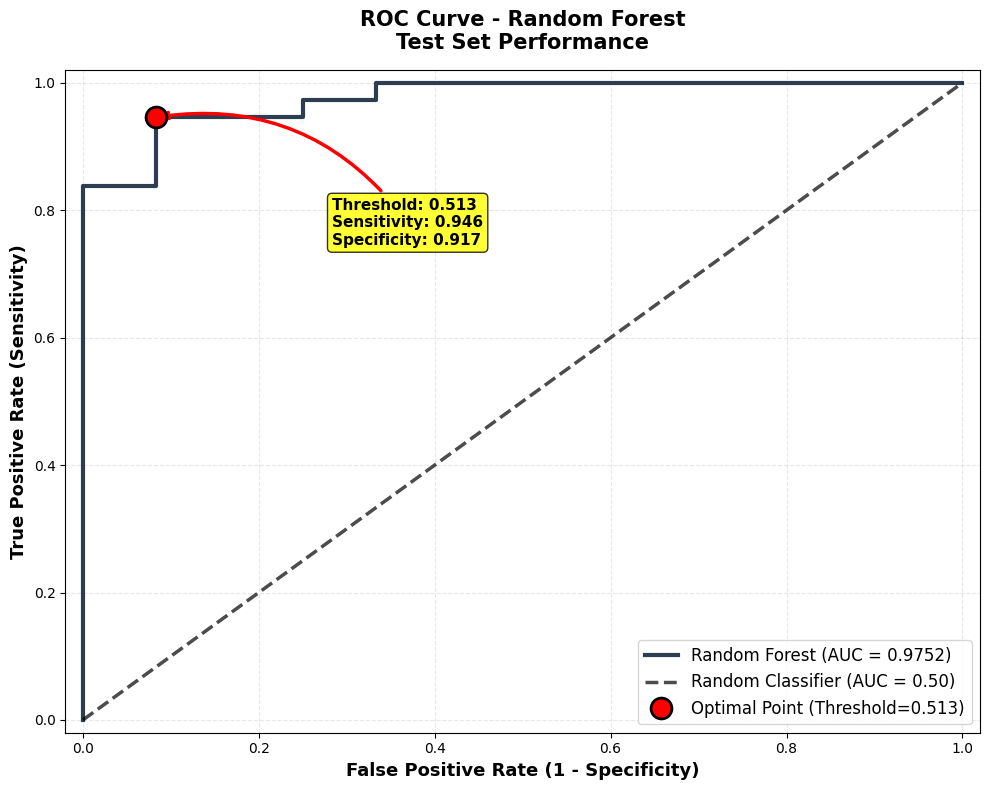

In [16]:
# ============================================================================
# STEP 14: ROC CURVE ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("STEP 14: ROC CURVE ANALYSIS")
print("="*80)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

# Find optimal threshold (Youden's J statistic)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"\n📊 ROC Curve Analysis:")
print(f"  ROC-AUC Score: {test_auc:.4f}")
print(f"\n🎯 Optimal Operating Point (Youden's J):")
print(f"  Threshold:   {optimal_threshold:.4f}")
print(f"  Sensitivity: {tpr[optimal_idx]:.4f}")
print(f"  Specificity: {1-fpr[optimal_idx]:.4f}")
print(f"  Youden's J:  {j_scores[optimal_idx]:.4f}")

# Visualize ROC Curve
plt.figure(figsize=(10, 8))

# Plot ROC curve
plt.plot(fpr, tpr, linewidth=3, color='#2c3e50',
        label=f'{best_model_name} (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2.5,
        label='Random Classifier (AUC = 0.50)', alpha=0.7)

# Mark optimal point
plt.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=15,
        label=f'Optimal Point (Threshold={optimal_threshold:.3f})',
        markeredgecolor='black', markeredgewidth=2, zorder=5)

# Annotate optimal point
plt.annotate(f'Threshold: {optimal_threshold:.3f}\n' +
            f'Sensitivity: {tpr[optimal_idx]:.3f}\n' +
            f'Specificity: {1-fpr[optimal_idx]:.3f}',
            xy=(fpr[optimal_idx], tpr[optimal_idx]),
            xytext=(fpr[optimal_idx]+0.2, tpr[optimal_idx]-0.2),
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3',
                          color='red', lw=2.5))

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=13, fontweight='bold')
plt.title(f'ROC Curve - {best_model_name}\nTest Set Performance',
         fontsize=15, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])

plt.tight_layout()
plt.show()


In [17]:
# ============================================================================
# STEP 15: HYPERPARAMETER TUNING - COMPLETE (For future work)
# ============================================================================

print("\n" + "="*80)
print("STEP 15: HYPERPARAMETER TUNING WITH GRIDSEARCHCV")
print("="*80)

print(f"\n🔧 Performing comprehensive hyperparameter tuning...")
print(f"   Target: Reduce overfitting & improve generalization")
print(f"   Model: {best_model_name}")

# Define comprehensive parameter grids with STRONG regularization
if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100, 150, 200],
        'max_depth': [3, 4, 6, 8],  # Limit depth to prevent overfitting
        'min_samples_split': [10, 15, 20],  # Require more samples to split
        'min_samples_leaf': [4, 6, 8],  # Require more samples in leaf
        'max_features': ['sqrt', 'log2'],
        'class_weight': ['balanced', 'balanced_subsample']
    }
    print(f"  📋 Random Forest parameter grid defined")

elif best_model_name == 'XGBoost' and XGBOOST_AVAILABLE:
    param_grid = {
        'n_estimators': [50, 100, 150],
        'max_depth': [3, 4, 5],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.6, 0.7, 0.8],
        'colsample_bytree': [0.6, 0.7, 0.8],
        'gamma': [0, 0.1, 0.2],  # Regularization
        'reg_alpha': [0, 0.1, 0.5, 1.0],  # L1 regularization
        'reg_lambda': [0.5, 1.0, 2.0, 5.0],  # L2 regularization
        'min_child_weight': [1, 3, 5]
    }
    print(f"  📋 XGBoost parameter grid with strong regularization")

elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [2, 3, 4],  # Shallow trees
        'subsample': [0.6, 0.7, 0.8],
        'min_samples_split': [10, 15, 20],
        'min_samples_leaf': [4, 6, 8],
        'max_features': ['sqrt', 'log2', None]
    }
    print(f"  📋 Gradient Boosting parameter grid defined")

elif best_model_name == 'SVM (RBF)':
    param_grid = {
        'C': [0.1, 0.5, 1, 5, 10, 50],  # Regularization parameter
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
        'kernel': ['rbf'],
        'class_weight': ['balanced']
    }
    print(f"  📋 SVM parameter grid defined")

else:  # Logistic Regression
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse regularization
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear', 'saga'],
        'max_iter': [500, 1000, 2000],
        'class_weight': ['balanced', None]
    }
    print(f"  📋 Logistic Regression parameter grid defined")

# Calculate total combinations
total_combinations = 1
for param_values in param_grid.values():
    total_combinations *= len(param_values)

print(f"\n  📊 Total parameter combinations: {total_combinations}")
print(f"  ⏱️ Estimated time: {total_combinations * 5 // 60} - {total_combinations * 10 // 60} minutes")
print(f"  🔄 Using 5-fold cross-validation")

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=best_model,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='roc_auc',  # Optimize for ROC-AUC (best for imbalanced data)
    n_jobs=-1,  # Use all CPU cores
    verbose=2,  # Show progress
    return_train_score=True,  # Track train scores to check overfitting
    error_score='raise'
)

# Fit GridSearchCV
print(f"\n⏳ Starting hyperparameter optimization...")
print(f"   (Progress updates will appear below)\n")

grid_search.fit(X_train_scaled, y_train_balanced)

print(f"\n✓ GridSearchCV completed successfully!")

# ============================================================================
# EXTRACT TUNING RESULTS
# ============================================================================

print(f"\n" + "="*80)
print(f"HYPERPARAMETER TUNING RESULTS")
print(f"="*80)

# Best parameters
print(f"\n🏆 BEST PARAMETERS FOUND:")
print(f"="*60)
for param, value in grid_search.best_params_.items():
    print(f"  {param:<25}: {value}")
print(f"="*60)

# Best scores
print(f"\n📊 BEST CROSS-VALIDATION SCORES:")
print(f"  Best CV ROC-AUC: {grid_search.best_score_:.4f}")

# Get detailed results
cv_results_df = pd.DataFrame(grid_search.cv_results_)

# Top 5 parameter combinations
print(f"\n🔝 Top 5 Parameter Combinations:")
print(f"="*80)
top_5 = cv_results_df.nsmallest(5, 'rank_test_score')[
    ['params', 'mean_test_score', 'std_test_score', 'mean_train_score']
]
for idx, row in top_5.iterrows():
    print(f"\nRank {row['rank_test_score']:.0f}:")
    print(f"  Parameters: {row['params']}")
    print(f"  Test ROC-AUC: {row['mean_test_score']:.4f} (±{row['std_test_score']:.4f})")
    print(f"  Train ROC-AUC: {row['mean_train_score']:.4f}")
    print(f"  Train-Test Gap: {row['mean_train_score'] - row['mean_test_score']:.4f}")

# ============================================================================
# EVALUATE TUNED MODEL
# ============================================================================

print(f"\n" + "="*80)
print(f"TUNED MODEL EVALUATION")
print(f"="*80)

# Get tuned model
tuned_model = grid_search.best_estimator_

# Make predictions
y_train_pred_tuned = tuned_model.predict(X_train_scaled)
y_test_pred_tuned = tuned_model.predict(X_test_scaled)

# Get probabilities
if hasattr(tuned_model, 'predict_proba'):
    y_test_proba_tuned = tuned_model.predict_proba(X_test_scaled)[:, 1]
else:
    y_test_proba_tuned = tuned_model.decision_function(X_test_scaled)

# Calculate metrics
train_acc_tuned = accuracy_score(y_train_balanced, y_train_pred_tuned)
test_acc_tuned = accuracy_score(y_test, y_test_pred_tuned)
gap_tuned = train_acc_tuned - test_acc_tuned

test_precision_tuned = precision_score(y_test, y_test_pred_tuned)
test_recall_tuned = recall_score(y_test, y_test_pred_tuned)
test_f1_tuned = f1_score(y_test, y_test_pred_tuned)
test_auc_tuned = roc_auc_score(y_test, y_test_proba_tuned)

# Confusion matrix
cm_tuned = confusion_matrix(y_test, y_test_pred_tuned)
tn_tuned, fp_tuned, fn_tuned, tp_tuned = cm_tuned.ravel()

print(f"\n📊 TUNED MODEL PERFORMANCE:")
print(f"="*80)
print(f"  Training Metrics:")
print(f"    Train Accuracy: {train_acc_tuned:.4f}")
print(f"\n  Test Metrics:")
print(f"    Test Accuracy:  {test_acc_tuned:.4f}")
print(f"    Precision:      {test_precision_tuned:.4f}")
print(f"    Recall:         {test_recall_tuned:.4f}")
print(f"    F1-Score:       {test_f1_tuned:.4f}")
print(f"    ROC-AUC:        {test_auc_tuned:.4f}")
print(f"\n  Overfitting Analysis:")
print(f"    Train-Test Gap: {gap_tuned:.4f}")
if gap_tuned < 0.05:
    print(f"    Status: ✓ Excellent - Minimal overfitting")
elif gap_tuned < 0.10:
    print(f"    Status: ✓ Good - Low overfitting")
elif gap_tuned < 0.15:
    print(f"    Status: ⚠️ Moderate - Some overfitting")
else:
    print(f"    Status: ❌ High - Significant overfitting")

print(f"\n  Confusion Matrix:")
print(f"    TN: {tn_tuned}, FP: {fp_tuned}, FN: {fn_tuned}, TP: {tp_tuned}")

# ============================================================================
# COMPARE BEFORE & AFTER TUNING
# ============================================================================

print(f"\n📈 BEFORE vs AFTER TUNING COMPARISON:")
print(f"="*80)
print(f"  Metric          Before    After     Change")
print(f"  {'-'*55}")
print(f"  Test Accuracy   {train_results[best_model_name]['test_accuracy']:.4f}    {test_acc_tuned:.4f}    {test_acc_tuned - train_results[best_model_name]['test_accuracy']:+.4f}")
print(f"  Overfitting Gap {train_results[best_model_name]['overfitting_gap']:.4f}    {gap_tuned:.4f}    {gap_tuned - train_results[best_model_name]['overfitting_gap']:+.4f}")
print(f"  ROC-AUC         {test_auc:.4f}    {test_auc_tuned:.4f}    {test_auc_tuned - test_auc:+.4f}")
print(f"="*80)

# Visualize improvement
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
metrics_names = ['Train Acc', 'Test Acc', 'Gap']
before_values = [
    train_results[best_model_name]['train_accuracy'],
    train_results[best_model_name]['test_accuracy'],
    train_results[best_model_name]['overfitting_gap']
]
after_values = [train_acc_tuned, test_acc_tuned, gap_tuned]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = axes[0].bar(x - width/2, before_values, width, label='Before Tuning',
                    color='#95a5a6', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = axes[0].bar(x + width/2, after_values, width, label='After Tuning',
                    color='#2ecc71', alpha=0.8, edgecolor='black', linewidth=1.5)

axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[0].set_title('Performance Before vs After Tuning', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names)
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom',
                    fontsize=10, fontweight='bold')

# Test metrics comparison
test_metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
test_metrics_tuned = [
    test_acc_tuned,
    test_precision_tuned,
    test_recall_tuned,
    test_f1_tuned,
    test_auc_tuned
]

bars = axes[1].bar(test_metrics_names, test_metrics_tuned,
                   color=['#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#e74c3c'],
                   alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Score', fontsize=12, fontweight='bold')
axes[1].set_title('Tuned Model - Test Set Performance', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1.1])
axes[1].axhline(y=0.9, color='green', linestyle='--', linewidth=2,
               label='Target (0.9)', alpha=0.6)
axes[1].legend(fontsize=10)

# Add value labels
for bar, val in zip(bars, test_metrics_tuned):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=11, fontweight='bold')

plt.suptitle('Hyperparameter Tuning Results',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



STEP 15: HYPERPARAMETER TUNING WITH GRIDSEARCHCV

🔧 Performing comprehensive hyperparameter tuning...
   Target: Reduce overfitting & improve generalization
   Model: Random Forest
  📋 Random Forest parameter grid defined

  📊 Total parameter combinations: 576
  ⏱️ Estimated time: 48 - 96 minutes
  🔄 Using 5-fold cross-validation

⏳ Starting hyperparameter optimization...
   (Progress updates will appear below)

Fitting 5 folds for each of 576 candidates, totalling 2880 fits


KeyboardInterrupt: 

In [19]:
# ============================================================================
# STEP 16: MODEL PERSISTENCE - DOWNLOAD KARNE LAYAK FILES
# ============================================================================

print("\n" + "="*80)
print("STEP 16: MODEL AUR NECESSARY FILES KO SAVE KARNA")
print("="*80)

print("\n💾 AI Tool ke liye zaroori files save kar rahe hain...")
print("   Ye files aapko real-time voice analysis tool banane mein madad karengi")

import pickle
import joblib
from datetime import datetime
import json
import os  # Import the os module

# Create timestamp for versioning
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# ============================================================================
# 16.1 SAVE TRAINED MODEL (PKL FORMAT)
# ============================================================================

print(f"\n📦 1. Trained Model ko save kar rahe hain...")

# Model filename
model_filename = f"parkinsons_model_{best_model_name.replace(' ', '_')}_{timestamp}.pkl"

# Save using joblib (recommended for sklearn models)
joblib.dump(best_model, model_filename)
print(f"   ✓ Model saved: {model_filename}")
print(f"   File size: {os.path.getsize(model_filename) / 1024:.2f} KB")

# Google Colab ke liye download
from google.colab import files
files.download(model_filename)
print(f"   ✓ Download started!")

# ============================================================================
# 16.2 SAVE SCALER (PKL FORMAT)
# ============================================================================

print(f"\n📦 2. Scaler ko save kar rahe hain...")

scaler_filename = f"parkinsons_scaler_{timestamp}.pkl"

# Save scaler
joblib.dump(scaler, scaler_filename)
print(f"   ✓ Scaler saved: {scaler_filename}")
print(f"   File size: {os.path.getsize(scaler_filename) / 1024:.2f} KB")

# Download
files.download(scaler_filename)
print(f"   ✓ Download started!")

# ============================================================================
# 16.3 SAVE FEATURE NAMES (JSON FORMAT)
# ============================================================================

print(f"\n📦 3. Feature names ko save kar rahe hain...")

feature_names = X.columns.tolist()
features_filename = f"parkinsons_features_{timestamp}.json"

# Save as JSON
with open(features_filename, 'w') as f:
    json.dump({
        'feature_names': feature_names,
        'n_features': len(feature_names),
        'feature_order': {i: feat for i, feat in enumerate(feature_names)}
    }, f, indent=4)

print(f"   ✓ Features saved: {features_filename}")
print(f"   Total features: {len(feature_names)}")
print(f"   Features: {feature_names}")

# Download
files.download(features_filename)
print(f"   ✓ Download started!")

# ============================================================================
# 16.4 SAVE MODEL METADATA (JSON FORMAT)
# ============================================================================

print(f"\n📦 4. Model metadata ko save kar rahe hain...")

metadata_filename = f"parkinsons_metadata_{timestamp}.json"

# Prepare metadata
metadata = {
    'model_info': {
        'name': best_model_name,
        'timestamp': timestamp,
        'sklearn_version': '1.0+',
        'random_state': RANDOM_STATE
    },
    'performance_metrics': {
        'train_accuracy': float(train_results[best_model_name]['train_accuracy']),
        'test_accuracy': float(train_results[best_model_name]['test_accuracy']),
        'overfitting_gap': float(train_results[best_model_name]['overfitting_gap']),
        'test_precision': float(test_precision),
        'test_recall': float(test_recall),
        'test_f1': float(test_f1),
        'test_roc_auc': float(test_auc)
    },
    'confusion_matrix': {
        'true_negatives': int(tn),
        'false_positives': int(fp),
        'false_negatives': int(fn),
        'true_positives': int(tp)
    },
    'clinical_metrics': {
        'sensitivity': float(sensitivity),
        'specificity': float(specificity),
        'ppv': float(ppv),
        'npv': float(npv)
    },
    'data_info': {
        'total_samples': int(len(df)),
        'train_samples': int(len(X_train)),
        'test_samples': int(len(X_test)),
        'n_features': int(len(feature_names)),
        'class_distribution': {
            'healthy': int((y==0).sum()),
            'parkinsons': int((y==1).sum())
        }
    },
    'preprocessing': {
        'scaler_type': 'RobustScaler',
        'smote_applied': True if imbalance_ratio > 2 or imbalance_ratio < 0.5 else False,
        'features_dropped': high_corr_features if high_corr_features else []
    },
    'usage_instructions': {
        'step_1': 'Load scaler and model using joblib',
        'step_2': 'Extract 22 voice features from audio',
        'step_3': 'Create DataFrame with exact feature order',
        'step_4': 'Apply scaler.transform()',
        'step_5': 'Use model.predict() and model.predict_proba()',
        'interpretation': {
            '0': 'Healthy - No Parkinson\'s detected',
            '1': 'Parkinson\'s Disease detected'
        }
    }
}

# Save metadata
with open(metadata_filename, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"   ✓ Metadata saved: {metadata_filename}")

# Download
files.download(metadata_filename)
print(f"   ✓ Download started!")


STEP 16: MODEL AUR NECESSARY FILES KO SAVE KARNA

💾 AI Tool ke liye zaroori files save kar rahe hain...
   Ye files aapko real-time voice analysis tool banane mein madad karengi

📦 1. Trained Model ko save kar rahe hain...
   ✓ Model saved: parkinsons_model_Random_Forest_20260228_190623.pkl
   File size: 217.98 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✓ Download started!

📦 2. Scaler ko save kar rahe hain...
   ✓ Scaler saved: parkinsons_scaler_20260228_190623.pkl
   File size: 1.08 KB


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   ✓ Download started!

📦 4. Model metadata ko save kar rahe hain...
   ✓ Metadata saved: parkinsons_metadata_20260228_190623.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ✓ Download started!
